In [13]:
import tensorflow as tf
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from qkeras import QConv2D, QDense, quantizers, QActivation


In [6]:
data = sio.loadmat('../data/sat-6-full.mat')
X_train = data['train_x']
y_train = data['train_y']
X_test = data['test_x']
y_test = data['test_y']

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)

X_train = np.transpose(X_train, (3, 0, 1, 2))
X_test  = np.transpose(X_test,  (3, 0, 1, 2))

y_train = np.transpose(y_train, (1, 0))
y_test  = np.transpose(y_test,  (1, 0))

LR = 3e-4
BATCH_SIZE = 512
EPOCHS = 30

optimizer = tf.keras.optimizers.Adam(learning_rate=LR)
loss = "categorical_crossentropy"
metrics = ["accuracy"]

In [7]:
def build_float_model():

    model = models.Sequential()

    model.add(layers.Input(shape=(28, 28, 4)))

    # Conv1: 3x3 stride 2
    model.add(layers.Conv2D(32, (3,3), strides=2, activation="relu", padding="same"))

    # Conv2: 1x1 stride 1
    model.add(layers.Conv2D(64, (1,1), strides=1, activation="relu"))

    model.add(layers.Flatten())

    model.add(layers.Dense(128, activation="relu"))

    model.add(layers.Dense(6, activation="softmax"))

    return model

def compile_and_train(model, X_train, y_train, X_test, y_test):

    model.compile(
        optimizer=tf.keras.optimizers.Adam(LR),
        loss=loss,
        metrics=metrics
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        shuffle=True
    )

    return history

In [10]:
float_model = build_float_model()
history_float = compile_and_train(float_model, X_train, y_train, X_test, y_test)

Epoch 1/30
633/633 [==============================] - 11s 16ms/step - loss: 0.1845 - accuracy: 0.9374 - val_loss: 0.0930 - val_accuracy: 0.9665
Epoch 2/30
633/633 [==============================] - 10s 15ms/step - loss: 0.0716 - accuracy: 0.9754 - val_loss: 0.0628 - val_accuracy: 0.9781
Epoch 3/30
633/633 [==============================] - 10s 15ms/step - loss: 0.0578 - accuracy: 0.9807 - val_loss: 0.0498 - val_accuracy: 0.9840
Epoch 4/30
633/633 [==============================] - 10s 16ms/step - loss: 0.0512 - accuracy: 0.9828 - val_loss: 0.0462 - val_accuracy: 0.9855
Epoch 5/30
633/633 [==============================] - 10s 15ms/step - loss: 0.0482 - accuracy: 0.9834 - val_loss: 0.0426 - val_accuracy: 0.9865
Epoch 6/30
633/633 [==============================] - 10s 16ms/step - loss: 0.0427 - accuracy: 0.9856 - val_loss: 0.0446 - val_accuracy: 0.9838
Epoch 7/30
633/633 [==============================] - 10s 16ms/step - loss: 0.0394 - accuracy: 0.9867 - val_loss: 0.0387 - val_accuracy:

In [11]:
def build_qmodel():

    qbits = 8
    quant_w = quantizers.quantized_bits(qbits, 0, alpha=1)
    quant_a = quantizers.quantized_bits(qbits, 0, alpha=1)

    model = models.Sequential()

    model.add(layers.Input(shape=(28, 28, 4)))

    model.add(QActivation(quant_a))

    model.add(QConv2D(
        32, (3,3),
        strides=2,
        padding="same",
        kernel_quantizer=quant_w,
        bias_quantizer=quant_w,
    ))
    model.add(QActivation(quant_a))

    model.add(QConv2D(
        64, (1,1),
        strides=1,
        padding="valid",
        kernel_quantizer=quant_w,
        bias_quantizer=quant_w,
    ))
    model.add(QActivation(quant_a))

    model.add(layers.Flatten())

    model.add(QDense(
        128,
        kernel_quantizer=quant_w,
        bias_quantizer=quant_w,
    ))
    model.add(QActivation(quant_a))

    model.add(QDense(
        6,
        kernel_quantizer=quant_w,
        bias_quantizer=quant_w,
        activation="softmax"
    ))

    return model

In [12]:
q_model = build_qmodel()
history_q = compile_and_train(q_model, X_train, y_train, X_test, y_test)


Epoch 1/30
633/633 [==============================] - 22s 34ms/step - loss: 0.2888 - accuracy: 0.8976 - val_loss: 0.1982 - val_accuracy: 0.9303
Epoch 2/30
633/633 [==============================] - 21s 34ms/step - loss: 0.1964 - accuracy: 0.9322 - val_loss: 0.1751 - val_accuracy: 0.9410
Epoch 3/30
633/633 [==============================] - 21s 33ms/step - loss: 0.1839 - accuracy: 0.9351 - val_loss: 0.1867 - val_accuracy: 0.9333
Epoch 4/30
633/633 [==============================] - 21s 33ms/step - loss: 0.1931 - accuracy: 0.9292 - val_loss: 0.2124 - val_accuracy: 0.9210
Epoch 5/30
633/633 [==============================] - 21s 34ms/step - loss: 0.1964 - accuracy: 0.9251 - val_loss: 0.1925 - val_accuracy: 0.9270
Epoch 6/30
633/633 [==============================] - 22s 34ms/step - loss: 0.1724 - accuracy: 0.9375 - val_loss: 0.1578 - val_accuracy: 0.9469
Epoch 7/30
633/633 [==============================] - 22s 35ms/step - loss: 0.1586 - accuracy: 0.9426 - val_loss: 0.1544 - val_accuracy:

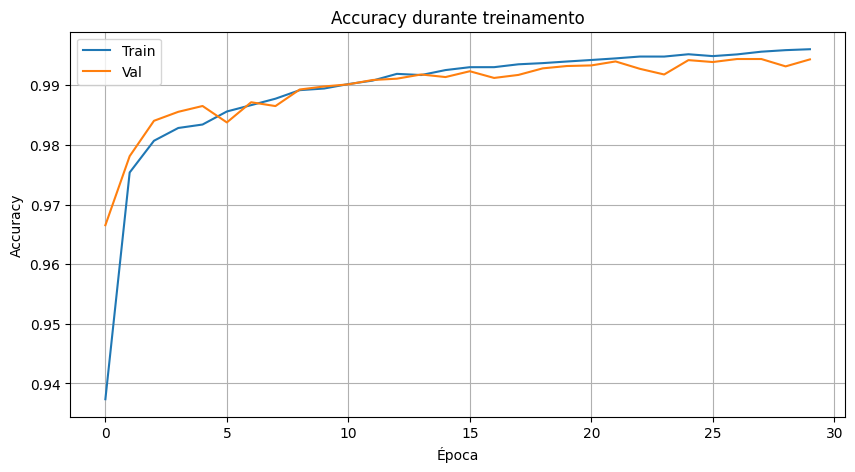

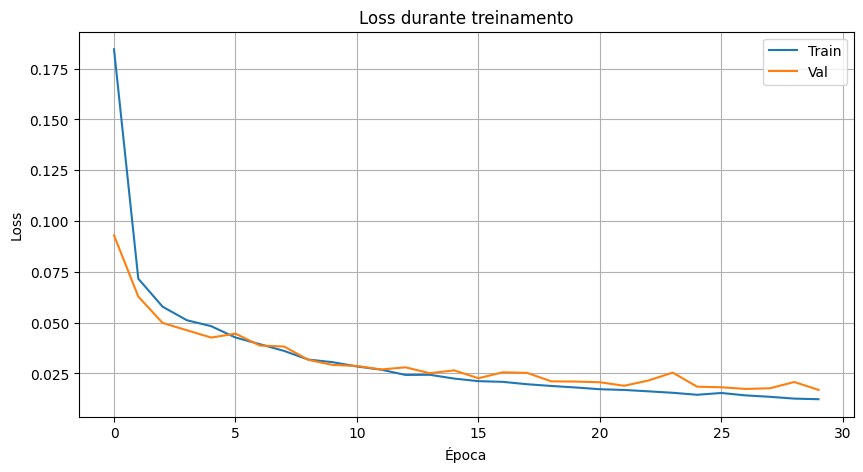

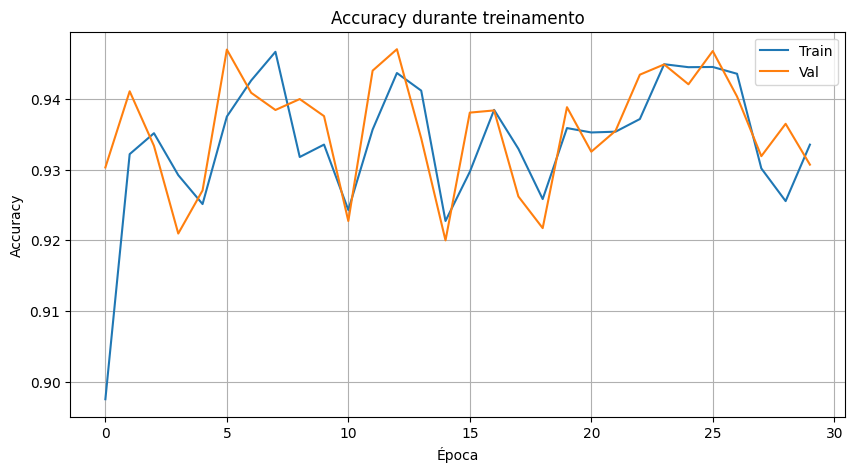

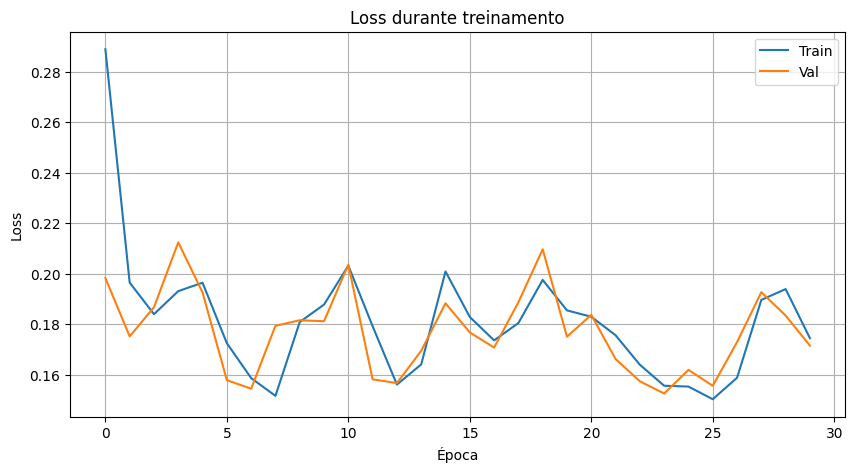

In [14]:
def plot_history(history):
    # Plotar acurácia
    plt.figure(figsize=(10,5))

    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')

    plt.xlabel('Época')
    plt.ylabel('Accuracy')
    plt.title('Accuracy durante treinamento')
    plt.legend()
    plt.grid(True)

    plt.show()

    # Plotar loss
    plt.figure(figsize=(10,5))

    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')

    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.title('Loss durante treinamento')
    plt.legend()
    plt.grid(True)

    plt.show()

plot_history(history_float)
plot_history(history_q)

In [15]:
float_model.evaluate(X_test, y_test, verbose=0)

[0.01689794845879078, 0.9943333268165588]

In [16]:
q_model.evaluate(X_test, y_test, verbose=0)

[0.1714765876531601, 0.9306913614273071]

Classe real: 5
Classe prevista: 5


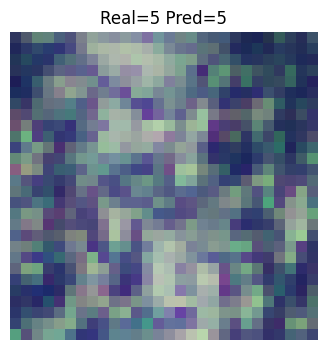

In [23]:
idx = 2

img = X_test[idx]
label = y_test[idx]

pred = float_model.predict(
    np.expand_dims(img, axis=0),
    verbose=0
)

pred_class = np.argmax(pred)
true_class = np.argmax(label)

print("Classe real:", true_class)
print("Classe prevista:", pred_class)

plt.figure(figsize=(4,4))

plt.imshow(img[:, :, :3])

plt.title(
    f"Real={true_class} Pred={pred_class}"
)

plt.axis('off')
plt.show()

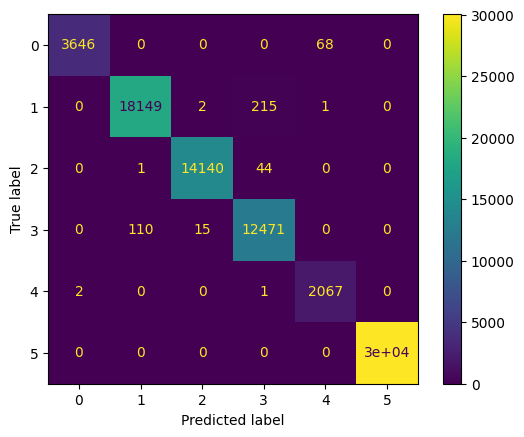

In [18]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = float_model.predict(X_test, verbose=0)

y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(cm)

disp.plot()
plt.show()

In [19]:
preds = float_model.predict(X_test, verbose=0)

preds = np.argmax(preds, axis=1)
truth = np.argmax(y_test, axis=1)

errors = np.where(preds != truth)[0]

print("Número de erros:", len(errors))

Número de erros: 459


In [20]:
float_model.save("cnn_float.h5")
q_model.save("cnn_quant.h5")

/home/fauri/Documentos/hls4ml/.venv_hls4ml_t/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
